# Supporting 3 - ML methods and studies in detail

*Optional detail; start with `notebooks/00_START_HERE.ipynb`.*

Reads what `scripts/run_pipeline.py` wrote for the small demo configuration. Every split is grouped by reservoir realisation; the test reservoirs are fresh reservoirs generated with their own seed and used once, at the end.

In [1]:
import sys, json, time
from pathlib import Path
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'pyproject.toml').exists())
sys.path.insert(0, str(ROOT / 'src'))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from IPython.display import Image, display
from subsurfaceml.config import load_config

CONFIG = 'demo'                 # which completed run this notebook reads
cfg = load_config(ROOT / 'config' / f'{CONFIG}.yaml')
S = json.loads((Path(cfg.paths.metrics) / 'summary.json').read_text())
pd.set_option('display.max_colwidth', 80)
plt.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': .3,
                     'font.size': 9, 'figure.constrained_layout.use': True})


def provenance(kind, what):
    """Label every result: read from a finished run, or computed right here."""
    label = {'loaded': 'LOADED from the completed ' + CONFIG + ' run',
             'computed': 'COMPUTED NOW in this notebook session'}[kind]
    print(f'[{label}]  {what}')
df = pd.read_csv(Path(cfg.paths.data)/'scenarios_features.csv')
print(len(df), 'development scenarios,', df.realisation_id.nunique(), 'realisations')
print('rows per role:', S['ml']['leakage']['rows'], '| overlaps:', S['ml']['leakage']['overlaps'])
print(json.dumps(S['data_quality'], indent=1))

300 development scenarios, 100 realisations
rows per role: {'train': 243, 'calib': 57, 'test': 90, 'shift': 45} | overlaps: {'train_calib': 0, 'train_test': 0, 'train_shift': 0, 'calib_test': 0, 'calib_shift': 0, 'test_shift': 0}
{
 "n_rows": 300,
 "n_failed_runs": 0,
 "duplicate_scenario_ids": 0,
 "duplicate_input_rows": 0,
 "missing_values_total": 0,
 "constant_columns_dropped_from_analysis": [
  "n_layers",
  "mass_lost_kg",
  "sg_min",
  "n_clipped",
  "max_clip",
  "max_bhp_spread_Pa",
  "sg_threshold",
  "p_limit_Pa",
  "mass_lost_Mt"
 ],
 "scenarios_with_a_rate_on_the_floor_or_ceiling": 0,
 "checks": {
  "saturation_in_bounds": true,
  "mass_balance_below_1e-9": true,
  "no_clipping": true,
  "positive_buildup": true,
  "common_bhp_below_1Pa": true
 },
 "duplicate_rows_dropped": 0
}


## Model comparison (course families) and held-out errors in physical units

In [2]:
rows = []
for t, r in S['ml']['targets'].items():
    rows.append({'target': t, 'unit': r['unit'], 'selected': r['selected_model'],
                 'test MAE': r['test']['MAE'], 'test RMSE': r['test']['RMSE'], 'test R2': r['test']['R2'],
                 'max |error|': r['test']['max_abs_error'], 'mean-baseline RMSE': r['mean_baseline_test_rmse'],
                 'interval case coverage': r['interval_test']['case_coverage'],
                 'reservoirs fully covered': r['interval_test']['reservoir_all_covered'],
                 'shift RMSE': r['shift']['RMSE']})
display(pd.DataFrame(rows))
print('grouped-CV RMSE of every family (training reservoirs; the only basis of selection):')
display(pd.DataFrame({t: r['model_comparison_cv_rmse'] for t, r in S['ml']['targets'].items()}))

,target,unit,selected,test MAE,test RMSE,test R2,max |error|,mean-baseline RMSE,interval case coverage,reservoirs fully covered,shift RMSE
0,dp_bh_max_MPa,MPa,svr,0.165559,0.527514,0.991817,4.230547,5.876021,1.000000,1.000000,0.635749
1,r_plume_m95_m,m,elasticnet,8.007935,13.209452,0.992827,64.379586,157.259655,0.944444,0.900000,9.210857
2,sweep_efficiency,-,elasticnet,0.001232,0.001698,0.978134,0.007094,0.011569,0.988889,0.966667,0.001568


grouped-CV RMSE of every family (training reservoirs; the only basis of selection):


,dp_bh_max_MPa,r_plume_m95_m,sweep_efficiency
mean,0.493894,153.340490,0.011083
linear,0.352862,8.081025,0.001758
ridge,0.312330,8.536219,0.001735
lasso,0.323156,10.053702,0.002392
elasticnet,0.323205,7.969990,0.001713
knn,0.377819,57.692981,0.004492
svr,0.295211,16.704204,0.002418
tree,0.425327,21.250571,0.002610
random_forest,0.384957,18.210102,0.002112
gradient_boosting,0.362493,13.312920,0.001857


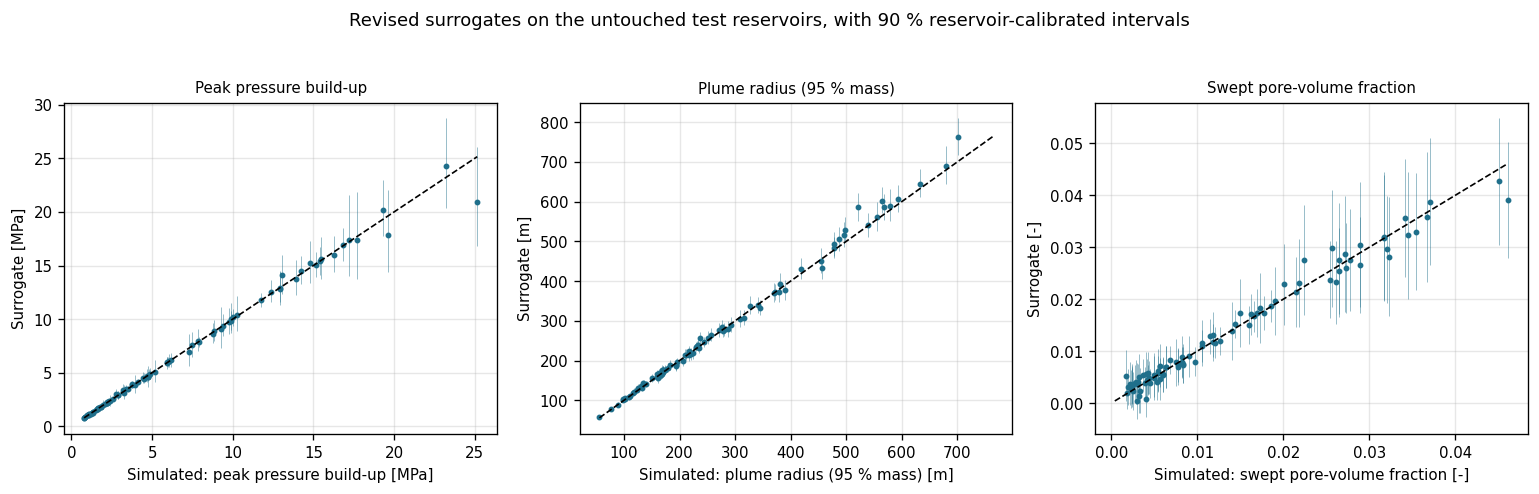

In [3]:
display(Image(str(Path(cfg.paths.figures)/'06_surrogate_parity.png')))

## Where the surrogates fail

In [4]:
for t, r in S['ml']['targets'].items():
    h = r['difficult_cases']
    print(f"\n{t}: worst 10% of test cases carry {100*h['share_of_total_abs_error_from_worst_10pct']:.0f}% of the absolute error")
    display(pd.DataFrame(h['worst_cases']).round(3))
    display(pd.DataFrame(h['by_permeability_tercile']))
    display(pd.DataFrame(h['by_schedule_intensity_tercile']))


dp_bh_max_MPa: worst 10% of test cases carry 70% of the absolute error


,scenario_id,dp_bh_max_MPa,pred,abs_err,rel_err,k_median_mD,V_DP,h_total_m,r_e_m,q_mult_mean,r_fill_over_re
0,R10006_S+02,25.159,20.929,4.231,0.168,32.837,0.115,45.586,2224.658,3.171,0.112
1,R10007_S+00,19.608,17.828,1.780,0.091,47.787,0.372,49.667,2444.291,2.707,0.117
2,R10028_S+00,13.028,14.079,1.051,0.081,158.855,0.759,37.463,3482.770,2.708,0.116
3,R10021_S+00,23.217,24.248,1.031,0.044,36.783,0.832,49.358,2229.659,3.484,0.122
4,R10028_S+01,19.342,20.194,0.851,0.044,158.855,0.759,37.463,3482.770,2.936,0.120


,k_bin,n,MAE,median_rel_err
0,low k,30,0.341392,0.022760
1,mid k,30,0.118499,0.007992
2,high k,30,0.036786,0.005080


,q_bin,n,MAE,median_rel_err
0,gentle,30,0.014710,0.007810
1,moderate,30,0.079957,0.013299
2,aggressive,30,0.402011,0.009642



r_plume_m95_m: worst 10% of test cases carry 41% of the absolute error


...

,q_bin,n,MAE,median_rel_err
0,gentle,30,3.839504,0.018331
1,moderate,30,5.359763,0.027378
2,aggressive,30,14.824538,0.025809



sweep_efficiency: worst 10% of test cases carry 32% of the absolute error


,scenario_id,sweep_efficiency,pred,abs_err,rel_err,k_median_mD,V_DP,h_total_m,r_e_m,q_mult_mean,r_fill_over_re
0,R10024_S+00,0.046,0.039,0.007,0.154,236.110,0.529,58.088,1359.990,3.131,0.142
1,R10001_S+00,0.022,0.028,0.005,0.230,334.337,0.297,74.984,1980.530,2.480,0.123
2,R10021_S+00,0.026,0.030,0.004,0.161,36.783,0.832,49.358,2229.659,3.484,0.122
3,R10028_S+00,0.032,0.028,0.004,0.126,158.855,0.759,37.463,3482.770,2.708,0.116
4,R10010_S+00,0.002,0.005,0.004,2.003,45.471,0.753,73.256,2375.113,0.159,0.027


,k_bin,n,MAE,median_rel_err
0,low k,30,0.001043,0.065134
1,mid k,30,0.001338,0.078050
2,high k,30,0.001316,0.118056


,q_bin,n,MAE,median_rel_err
0,gentle,30,0.001177,0.322650
1,moderate,30,0.000620,0.060897
2,aggressive,30,0.001900,0.054780


## Pressure-limit screening

,oof_roc_auc,oof_average_precision
logistic,0.996101,0.988581
knn,0.970638,0.943105
svc,0.995553,0.988864
tree,0.960892,0.920250
random_forest,0.999391,0.998062
xgboost,0.997777,0.993585


imbalance handling (logistic, out-of-fold, threshold 0.5):


,precision,recall,f1,roc_auc,average_precision
none,0.943662,0.930556,0.937063,0.996101,0.988581
class_weight_balanced,0.918919,0.944444,0.931507,0.995797,0.987556
random_oversampling,0.918919,0.944444,0.931507,0.995797,0.987413
random_undersampling,0.884615,0.958333,0.920000,0.993604,0.983157
smote,0.929577,0.916667,0.923077,0.995736,0.987244


test_default_threshold {'accuracy': 0.9777777777777777, 'precision': 0.9615384615384616, 'recall': 0.9615384615384616, 'f1': 0.9615384615384616, 'confusion_matrix': [[63, 1], [1, 25]], 'roc_auc': 0.9993990384615384, 'average_precision': 0.9985754985754987}
test_selected_threshold {'accuracy': 0.9777777777777777, 'precision': 0.9615384615384616, 'recall': 0.9615384615384616, 'f1': 0.9615384615384616, 'confusion_matrix': [[63, 1], [1, 25]], 'roc_auc': 0.9993990384615384, 'average_precision': 0.9985754985754987}
test_regression_surrogate_thresholded {'accuracy': 1.0, 'precision': 1.0, 'recall': 1.0, 'f1': 1.0, 'confusion_matrix': [[64, 0], [0, 26]]}
interval upper edge as the screen: {'n': 90, 'n_exceeding': 26, 'missed_exceedances': 0, 'false_alarms': 3, 'declared_safe': 61}


,oof_macro_f1,oof_accuracy
logistic_multinomial,0.788590,0.933333
logistic_ovr,0.722636,0.936667
logistic_ovo,0.790236,0.933333
knn,0.674055,0.903333
random_forest,0.830791,0.960000


test: {'macro_f1': 0.8123025123025123, 'accuracy': 0.9555555555555556, 'per_class_recall': [1.0, 0.3333333333333333, 1.0], 'confusion_matrix': [[58, 0, 0], [1, 2, 3], [0, 0, 26]]}


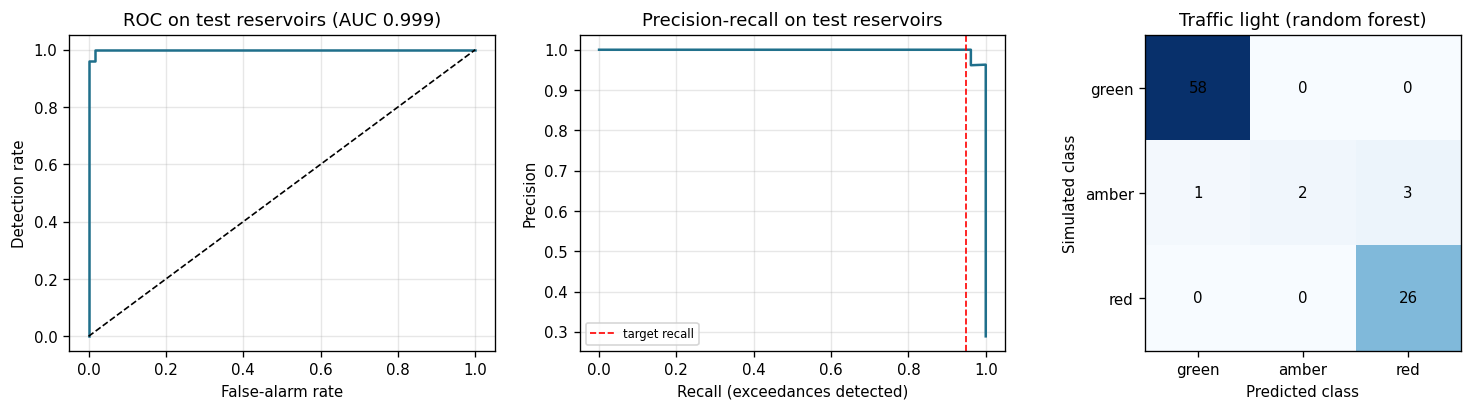

In [5]:
b = S['classifier']['binary']
display(pd.DataFrame(b['families']).T)
print('imbalance handling (logistic, out-of-fold, threshold 0.5):')
display(pd.DataFrame(b['imbalance_study_logistic_oof']).T)
for k in ('test_default_threshold', 'test_selected_threshold', 'test_regression_surrogate_thresholded'):
    print(k, {kk: v for kk, v in b[k].items()})
print('interval upper edge as the screen:', b['test_regression_upper_bound'])
tl = S['classifier']['traffic_light']
display(pd.DataFrame(tl['families']).T); print('test:', tl['test'])
display(Image(str(Path(cfg.paths.figures)/'10_classifier.png')))

## Uncertainty: Monte Carlo over the assumed prior and error sources

In [6]:
for t, r in S['uncertainty']['targets'].items():
    print(t, {k: round(v, 4) for k, v in r['monte_carlo_prior'].items() if isinstance(v, float)})
    e = r['error_sources']; print('   shares input/surrogate/numerical %:',
          round(e['share_input_pct'], 1), round(e['share_surrogate_pct'], 1), round(e['share_numerical_pct'], 1))

dp_bh_max_MPa {'mean': 5.717, 'std': 5.0494, 'P90_low_case': 0.9812, 'P50': 3.9731, 'P10_high_case': 13.9776}
   shares input/surrogate/numerical %: 98.9 1.1 0.0
r_plume_m95_m {'mean': 251.5509, 'std': 148.5715, 'P90_low_case': 106.0669, 'P50': 202.1349, 'P10_high_case': 464.4011}
   shares input/surrogate/numerical %: 99.0 0.8 0.2
sweep_efficiency {'mean': 0.0124, 'std': 0.011, 'P90_low_case': 0.0019, 'P50': 0.0087, 'P10_high_case': 0.03}
   shares input/surrogate/numerical %: 97.3 2.3 0.4


## ML-method studies (training reservoirs only)


## scaler_comparison
{
 "knn": {
  "none": 0.06617045045615398,
  "standard": 0.0428674741757118,
  "minmax": 0.04279771441067061,
  "robust": 0.04241560261533652
 },
 "svr": {
  "none": 0.0697266669031564,
  "standard": 0.058969998204491725,
  "minmax": 0.058127751665000116,
  "robust": 0.059708472299171964
 },
 "ridge": {
  "none": 0.04068481097570631,
  "standard": 0.03984417896492016,
  "minmax": 0.04077322034507825,
  "robust": 0.03989203144806949
 }
}

## missing_descriptors
{
 "permeability": {
  "columns": [
   "log10_k_mD",
   "log10_kh",
   "log10_injectivity",
   "log10_q_ref",
   "log10_q_mult_mean",
   "q_mult_max"
  ],
  "mean": 0.04618126837423996,
  "median": 0.04722881260602917,
  "drop_feature": 0.04490191680536414,
  "complete": 0.046040625115102964
 },
 "Dykstra-Parsons": {
  "columns": [
   "V_DP",
   "V_DP_layers"
  ],
  "mean": 0.046104409407361754,
  "median": 0.046112974711151125,
  "drop_feature": 0.045840113750099984,
  "complete": 0.046040625115102964
 },
 

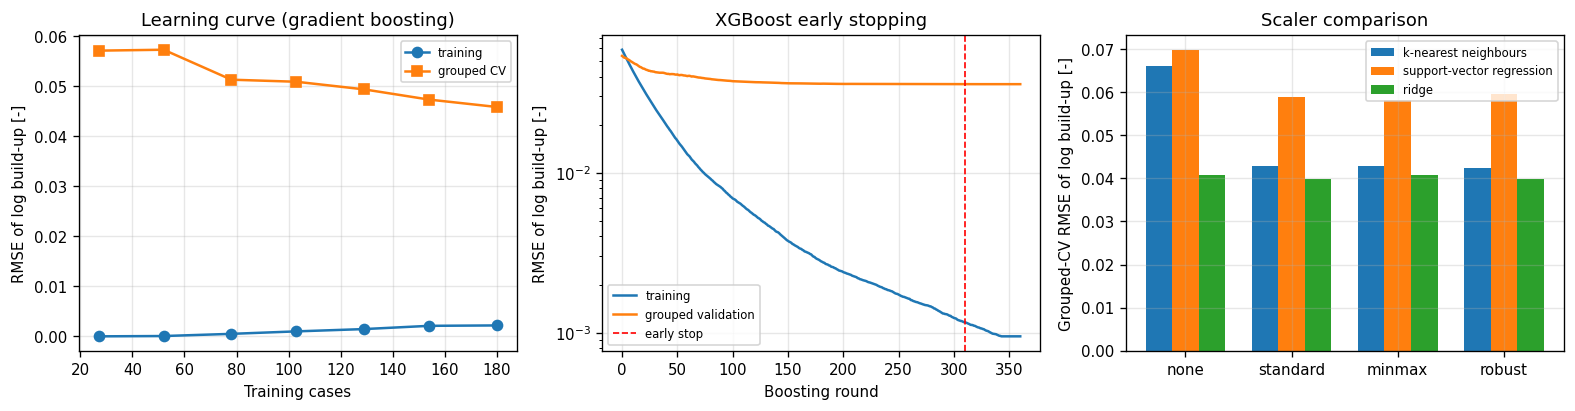

In [7]:
st = S['studies']
for k in ('scaler_comparison', 'missing_descriptors', 'outliers', 'polynomial', 'column_transformer',
          'split_comparison', 'ensembles', 'normal_equation'):
    v = st[k]; print('\n##', k)
    print(json.dumps({a: b for a, b in v.items() if a != 'gd_cost_history_every_500'}, indent=1, default=str)[:1500])
print(json.dumps({k: st['feature_selection'][k] for k in st['feature_selection']}, indent=1)[:2000])
print(json.dumps({k: {kk: vv for kk, vv in v.items() if kk != 'best'} for k, v in st['tuning_strategies'].items()}, indent=1))
display(Image(str(Path(cfg.paths.figures)/'14_ml_studies.png')))

## Interpretation (model behaviour, not causality) and plume shapes

,feature,importance_mean,importance_std
0,log10_rom_dp_MPa,7.677334,0.428172
1,n_a,0.121799,0.046656
2,n_g,0.063201,0.051344
3,krg0,0.059659,0.043227
4,log10_mobility_ratio,0.044399,0.053499
5,log10_q_mult_mean,0.019165,0.008979
6,r_fill_over_re,0.019137,0.009324
7,dimensionless_mass,0.017443,0.009299


,feature,mean_abs_shap
0,log10_mobility_ratio,0.010234
1,n_g,0.009964
2,log10_k_harm_mD,0.009287
3,rom_max_layer_share,0.008690
4,r_e_m,0.007614
5,n_a,0.006352
6,krg0,0.005044
7,log10_kh_realised,0.003628


{
 "scenario_id": "R10008_S+01",
 "simulated_dp_MPa": 8.841273091500506,
 "predicted_dp_MPa": 8.855743096858141,
 "lime_top6": [
  {
   "feature": "log10_rom_dp_MPa",
   "local_effect_per_sd": 9.522844522611335
  },
  {
   "feature": "log10_mobility_ratio",
   "local_effect_per_sd": -0.20843561785755663
  },
  {
   "feature": "log10_kh",
   "local_effect_per_sd": -0.17185696099272568
  },
  {
   "feature": "q_mean_kg_s",
   "local_effect_per_sd": 0.14386881805247342
  },
  {
   "feature": "log10_q_mult_mean",
   "local_effect_per_sd": 0.13804674779181994
  },
  {
   "feature": "phi_mean",
   "local_effect_per_sd": 0.1367267175409094
  }
 ],
 "what_if": {
  "largest_rate_factor_predicted_below_limit": 1.0,
  "limit_MPa": 9.0
 }
}
{
 "n_profiles": 300,
 "n_bins": 24,
 "explained_variance_ratio": [
  0.6864641447834721,
  0.13871876372665443,
  0.09293855630965506,
  0.0432480515370796,
  0.017440451418791976,
  0.006620718386151536,
  0.0050000892617295045,
  0.004337974569783238
 ],
 "n

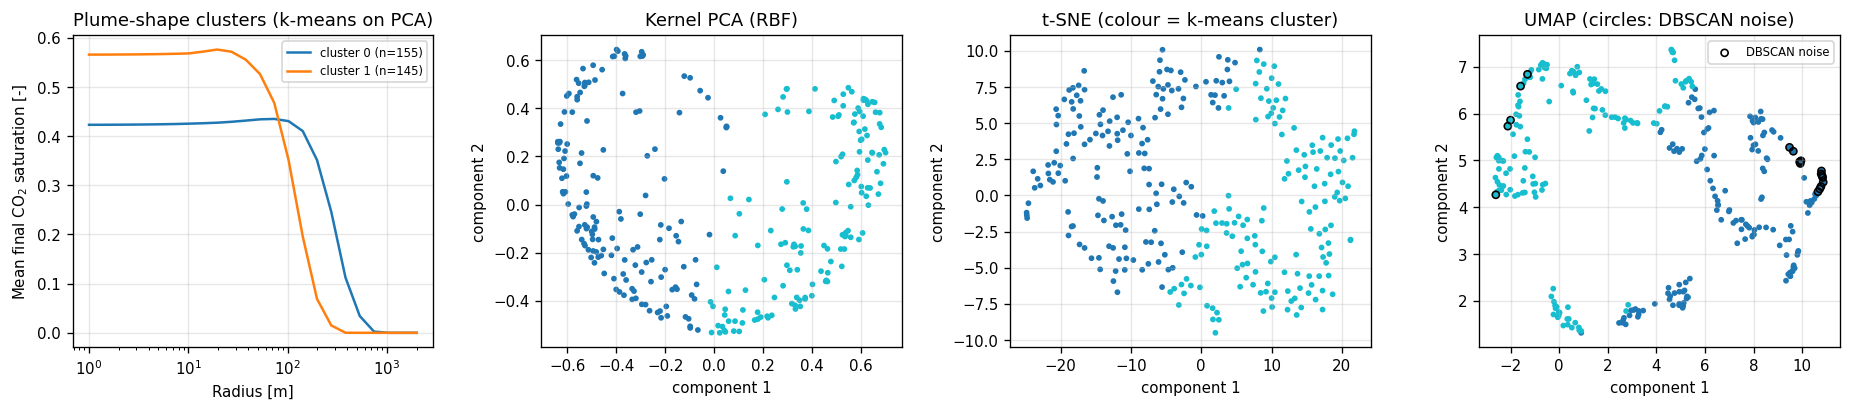

In [8]:
I = S['interpretation']
display(pd.DataFrame(I['dp_bh_max_MPa']['permutation_top8']))
if 'shap' in I: display(pd.DataFrame(I['shap']['top'][:8]))
print(json.dumps(I['local_case'], indent=1, default=str))
print(json.dumps(I.get('plume_shapes', {}), indent=1)[:1500])
display(Image(str(Path(cfg.paths.figures)/'13_plume_shapes.png')))

## Cost

In [9]:
print(json.dumps(S['speed'], indent=1))

{
 "hardware_note": "same machine, same process, 1 scenario at a time for the simulator; scikit-learn/XGBoost default threading",
 "n_test_rows_batch": 90,
 "surrogate_batch_seconds_total": 0.009381632000440732,
 "surrogate_seconds_per_case_batched": 0.00010424035556045257,
 "surrogate_seconds_single_call_median": 0.006648038000093948,
 "surrogate_seconds_single_end_to_end_median": 0.043128580999109545,
 "simulator_seconds_per_case_mean_serial": 0.608469508199778,
 "simulator_cases_timed": 5,
 "speedup_batched": 5837.177980910718,
 "speedup_single_call": 91.52617782737994,
 "speedup_single_end_to_end": 14.108266353867306,
 "outputs_compared": "the three scalar QoIs; the end-to-end time includes building the inputs and the analytical ROM; the simulator also yields fields and time series",
 "dataset_generation_wall_seconds": 48.835326283999166,
 "dataset_generation_cpu_seconds": 182.63738653599466,
 "surrogate_training_seconds": 140.382934397001
}
